In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================

# Path to the locally downloaded dataset
file_path = "yellow_tripdata_2023-01.parquet"

print("Loading NYC TLC Parquet data from local file...")

# Load the locally downloaded dataset
raw_df = pd.read_parquet(file_path)

# Randomly sample 100,000 records for computational efficiency
raw_df = raw_df.sample(
    n=100000,
    random_state=RANDOM_STATE
)

print("--- Raw Dataset Audit ---")

# Dataset shape
print(f"\nDataset Shape: {raw_df.shape}")

# Dataset information
print("\nDataset Information:")
raw_df.info()

# Data types
print("\nData Types:")
print(raw_df.dtypes)

# Missing values
print("\nMissing Values Count:")
print(raw_df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows Count:")
print(raw_df.duplicated().sum())

# Target distribution
print("\nTarget (Fare Amount) Distribution:")
print(raw_df["fare_amount"].describe())

print("\nFare Amount Value Counts (Top 10):")
print(raw_df["fare_amount"].value_counts().head(10))

Loading NYC TLC Parquet data from local file...
--- Raw Dataset Audit ---

Dataset Shape: (100000, 19)

Dataset Information:
<class 'pandas.DataFrame'>
Index: 100000 entries, 2790731 to 13812
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int64         
 1   tpep_pickup_datetime   100000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[us]
 3   passenger_count        97714 non-null   float64       
 4   trip_distance          100000 non-null  float64       
 5   RatecodeID             97714 non-null   float64       
 6   store_and_fwd_flag     97714 non-null   str           
 7   PULocationID           100000 non-null  int64         
 8   DOLocationID           100000 non-null  int64         
 9   payment_type           100000 non-null  int64         
 10  fare_amount            100000 non-null  float64   

In [4]:
print("\n--- First 5 Rows of the Dataset ---")
raw_df.head()


--- First 5 Rows of the Dataset ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2790731,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0
666153,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0
1985683,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0
2154231,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0
2493619,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0


In [5]:
print(raw_df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [6]:
# ==========================================
# 2. DATA CLEANING
# ==========================================

df = raw_df.copy()

# Datetime Parsing & Duration
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration_min'] = (
    (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
    .dt.total_seconds() / 60.0
)

# Check and remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Outlier and invalid-value filtering
# Thresholds are chosen to remove clearly unrealistic records
# while retaining valid taxi trips.
df = df[
    (df['trip_distance'] > 0.1) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 2.5) & (df['fare_amount'] < 300) &
    (df['trip_duration_min'] > 1.0) & (df['trip_duration_min'] < 180) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)
].copy()

# Fill missing numerical values using the median
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(
    df['congestion_surcharge'].median()
)

df['airport_fee'] = df['airport_fee'].fillna(
    df['airport_fee'].median()
)

# Fill missing categorical values using the most frequent category
df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
).astype(str)

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)

# Convert categorical ID column to string
df['payment_type'] = df['payment_type'].astype(str)

print("\n--- Data Cleaning Summary ---")
print(f"Records before cleaning: {raw_df.shape[0]}")
print(f"Records after cleaning: {df.shape[0]}")
print(f"Records removed: {raw_df.shape[0] - df.shape[0]}")
print(f"Duplicate rows found: {duplicates_before}")

print("\nRemaining Missing Values:")
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0])


--- Data Cleaning Summary ---
Records before cleaning: 100000
Records after cleaning: 93604
Records removed: 6396
Duplicate rows found: 0

Remaining Missing Values:
Series([], dtype: int64)


In [7]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)

df['PULocationID'] = df['PULocationID'].astype(str)
df['DOLocationID'] = df['DOLocationID'].astype(str)

X = df[['PULocationID', 'DOLocationID', 'day_of_week',
        'passenger_count', 'trip_distance', 'trip_duration_min',
        'pickup_hour', 'is_weekend']]
y = df['fare_amount']

num_features = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'is_weekend']
cat_features = ['PULocationID', 'DOLocationID', 'day_of_week']


In [11]:
# ==========================================
# 4. PREPROCESSING & TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Categorical feature encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), cat_features)
    ]
)

# Fit ONLY on Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Pipeline Status ---")
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"X_train Shape: {X_train_processed.shape}")
print(f"X_test Shape: {X_test_processed.shape}")


--- Pipeline Status ---
Cleaned Dataset Shape: (93604, 23)
X_train Shape: (74883, 450)
X_test Shape: (18721, 450)


C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [12]:
# ==========================================
# 5. PCA DIMENSIONALITY REDUCTION
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)

X_train_reduced = pca.fit_transform(X_train_processed)
X_test_reduced = pca.transform(X_test_processed)

print("\n--- PCA Dimensionality Reduction ---")
print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")


--- PCA Dimensionality Reduction ---
Original number of features: 450
Reduced number of features: 75
Variance retained: 0.9509


In [13]:
# CLASSIFICATION DATA PREPARATION

# Find class boundaries using ONLY training target
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.67)

# Create class labels using the same boundaries
bins = [-float('inf'), q1, q2, float('inf')]
labels = ['Low', 'Medium', 'High']

y_train_cls = pd.cut(
    y_train,
    bins=bins,
    labels=labels,
    include_lowest=True
)

y_test_cls = pd.cut(
    y_test,
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Use the same preprocessed features
X_train_cls = X_train_reduced
X_test_cls = X_test_reduced

print("Classification Class Distribution:")
print("\nTraining Data:")
print(y_train_cls.value_counts())

print("\nTest Data:")
print(y_test_cls.value_counts())

Classification Class Distribution:

Training Data:
fare_amount
Low       26359
Medium    24884
High      23640
Name: count, dtype: int64

Test Data:
fare_amount
Low       6606
Medium    6320
High      5795
Name: count, dtype: int64


In [16]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train
log_reg.fit(X_train_cls, y_train_cls)

# Predict
y_pred_lr = log_reg.predict(X_test_cls)

# Evaluate
lr_acc = accuracy_score(y_test_cls, y_pred_lr)
lr_f1 = f1_score(y_test_cls, y_pred_lr, average='weighted')
lr_prec = precision_score(y_test_cls, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test_cls, y_pred_lr, average='weighted')

print("Model 1: Logistic Regression")
print(f"Accuracy: {lr_acc:.4f} | F1-Score: {lr_f1:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f}")


Model 1: Logistic Regression
Accuracy: 0.9555 | F1-Score: 0.9555 | Precision: 0.9555 | Recall: 0.9555


In [17]:
# ==========================================
# MODEL 2: K-NEAREST NEIGHBORS CLASSIFIER
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Feature scaling for KNN
scaler_knn_cls = StandardScaler()

X_train_knn_scaled = scaler_knn_cls.fit_transform(X_train_cls)
X_test_knn_scaled = scaler_knn_cls.transform(X_test_cls)

# ==========================================
# K VALUE TUNING
# ==========================================

# Use reduced training sample for faster computation
sample_size = 20000

X_train_knn_tune = X_train_knn_scaled[:sample_size]
y_train_knn_tune = y_train_cls.iloc[:sample_size]

k_values = [3, 5, 7, 9]

results = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        n_jobs=-1
    )

    model.fit(X_train_knn_tune, y_train_knn_tune)

    predictions = model.predict(X_test_knn_scaled)

    results.append({
        'K Value': k,
        'Accuracy': accuracy_score(y_test_cls, predictions),
        'F1 Score': f1_score(
            y_test_cls, predictions,
            average='weighted',
            zero_division=0
        ),
        'Precision': precision_score(
            y_test_cls, predictions,
            average='weighted',
            zero_division=0
        ),
        'Recall': recall_score(
            y_test_cls, predictions,
            average='weighted',
            zero_division=0
        )
    })

knn_tuning_results = pd.DataFrame(results)

knn_tuning_results = knn_tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print("KNN Classifier K Value Tuning Results")
display(knn_tuning_results)

# Select best K automatically
best_k = int(knn_tuning_results.iloc[0]['K Value'])

# ==========================================
# FINAL KNN MODEL
# ==========================================

X_train_knn = X_train_knn_scaled[:sample_size]
y_train_knn = y_train_cls.iloc[:sample_size]

knn_cls = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)

knn_cls.fit(X_train_knn, y_train_knn)

y_pred_knn = knn_cls.predict(X_test_knn_scaled)

# Evaluate
knn_acc = accuracy_score(y_test_cls, y_pred_knn)

knn_f1 = f1_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

knn_prec = precision_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

knn_rec = recall_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

print("\nModel 2: K-Nearest Neighbors Classifier")
print(f"Best K Value: {best_k}")
print(f"Training Sample Size: {sample_size}")

print(
    f"Accuracy: {knn_acc:.4f} | "
    f"F1-Score: {knn_f1:.4f} | "
    f"Precision: {knn_prec:.4f} | "
    f"Recall: {knn_rec:.4f}"
)

print("\nDistance Metric:")
print("KNN uses Euclidean distance by default "
      "(Minkowski distance with p=2).")

KNN Classifier K Value Tuning Results


,K Value,Accuracy,F1 Score,Precision,Recall
0,7,0.737941,0.737492,0.737790,0.737941
1,9,0.737140,0.736345,0.736271,0.737140
2,5,0.735324,0.734973,0.735238,0.735324
3,3,0.731852,0.731634,0.731932,0.731852



Model 2: K-Nearest Neighbors Classifier
Best K Value: 7
Training Sample Size: 20000
Accuracy: 0.7379 | F1-Score: 0.7375 | Precision: 0.7378 | Recall: 0.7379

Distance Metric:
KNN uses Euclidean distance by default (Minkowski distance with p=2).


In [18]:
# Gaussian Naive Bayes


from sklearn.naive_bayes import GaussianNB

# Create and train the model
gnb = GaussianNB()
gnb.fit(X_train_cls, y_train_cls)

# Predict
y_pred_gnb = gnb.predict(X_test_cls)

# Evaluate
gnb_acc = accuracy_score(y_test_cls, y_pred_gnb)
gnb_f1 = f1_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)
gnb_prec = precision_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)
gnb_rec = recall_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)

# Display results
print("Model 3: Gaussian Naive Bayes")
print(
    f"Accuracy: {gnb_acc:.4f} | "
    f"F1-Score: {gnb_f1:.4f} | "
    f"Precision: {gnb_prec:.4f} | "
    f"Recall: {gnb_rec:.4f}"
)

Model 3: Gaussian Naive Bayes
Accuracy: 0.7863 | F1-Score: 0.7873 | Precision: 0.7909 | Recall: 0.7863


In [19]:
# ==========================================
# MODEL 4: DECISION TREE CLASSIFIER
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# ==========================================
# MAX DEPTH TUNING
# ==========================================

depth_values = [5, 10, 15, 20]

dt_tuning_results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_cls, y_train_cls)

    predictions = model.predict(X_test_cls)

    dt_tuning_results.append({
        'Max Depth': depth,
        'Accuracy': accuracy_score(y_test_cls, predictions),
        'F1 Score': f1_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        ),
        'Precision': precision_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        ),
        'Recall': recall_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        )
    })

dt_tuning_results = pd.DataFrame(dt_tuning_results)

dt_tuning_results = dt_tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print("Decision Tree Max Depth Tuning Results")
display(dt_tuning_results)

# Select best depth automatically
best_depth = int(
    dt_tuning_results.iloc[0]['Max Depth']
)

# ==========================================
# FINAL DECISION TREE MODEL
# ==========================================

dt_cls = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

dt_cls.fit(X_train_cls, y_train_cls)

# Predict
y_pred_dt = dt_cls.predict(X_test_cls)

# Evaluate
dt_acc = accuracy_score(y_test_cls, y_pred_dt)

dt_f1 = f1_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

dt_prec = precision_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

dt_rec = recall_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

print("\nModel 4: Decision Tree Classifier")
print(f"Best Max Depth: {best_depth}")
print(
    f"Accuracy: {dt_acc:.4f} | "
    f"F1-Score: {dt_f1:.4f} | "
    f"Precision: {dt_prec:.4f} | "
    f"Recall: {dt_rec:.4f}"
)

Decision Tree Max Depth Tuning Results


,Max Depth,Accuracy,F1 Score,Precision,Recall
0,10,0.947973,0.948042,0.948196,0.947973
1,5,0.944768,0.944834,0.945002,0.944768
2,15,0.941937,0.941965,0.942004,0.941937
3,20,0.938305,0.938250,0.938208,0.938305



Model 4: Decision Tree Classifier
Best Max Depth: 10
Accuracy: 0.9480 | F1-Score: 0.9480 | Precision: 0.9482 | Recall: 0.9480


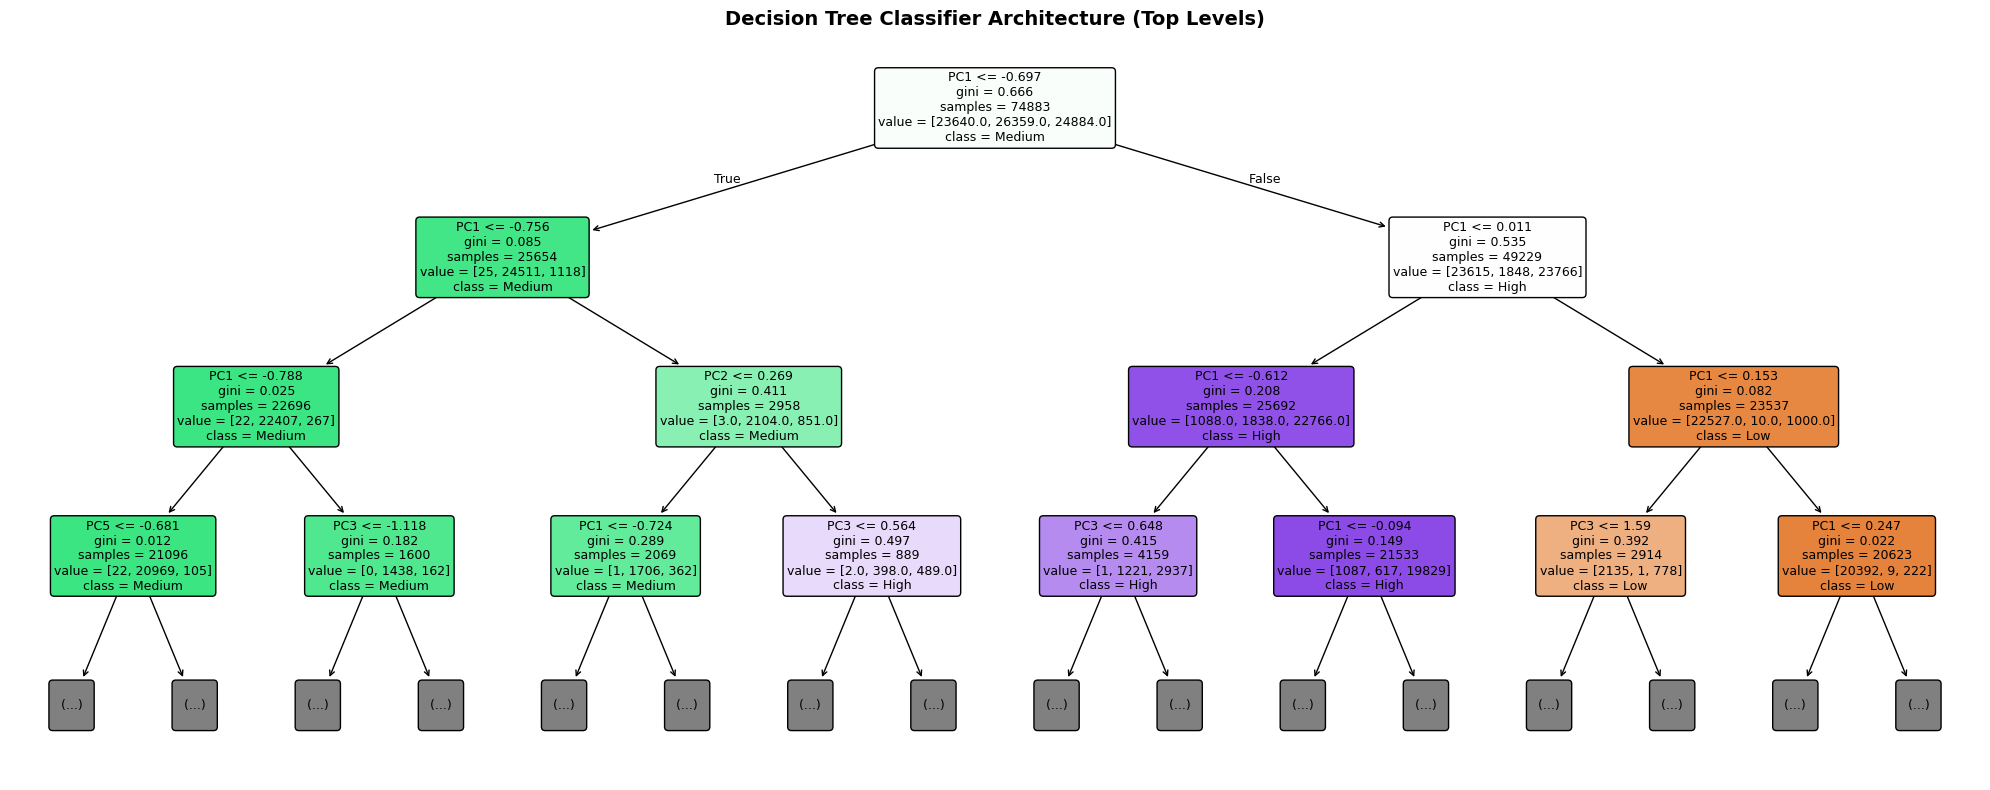

In [25]:
# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

plot_tree(
    dt_cls,
    max_depth=3,
    feature_names=[f'PC{i+1}' for i in range(X_train_cls.shape[1])],
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    'Decision Tree Classifier Architecture (Top Levels)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Decision Tree Visualization

The Decision Tree visualization shows the hierarchical decision-making process used by the classifier to separate the **Low, Medium, and High demand classes**.

- The tree makes decisions by applying threshold-based splits on the principal component features.
- The upper levels show the most influential splits used to separate the demand categories.
- Different leaf/node colours represent the predicted demand classes.
- The visualization demonstrates that the Decision Tree can model **non-linear relationships** in the classification problem.
- Only the top levels of the tuned tree are displayed to keep the visualization readable.

Overall, the visualization provides an interpretable view of how the Decision Tree progressively separates the three demand categories.

In [20]:
# ==========================================
# MODEL 5: SUPPORT VECTOR CLASSIFIER (SVC)
# ==========================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ==========================================
# SVC FEATURE SCALING
# ==========================================

scaler_svc = StandardScaler()

X_train_svc_scaled = scaler_svc.fit_transform(X_train_cls)
X_test_svc_scaled = scaler_svc.transform(X_test_cls)

# ==========================================
# SVC - TUNE C AND KERNEL
# ==========================================

SAMPLE_SIZE = 5000

X_train_svc_sample = X_train_svc_scaled[:SAMPLE_SIZE]
y_train_svc_sample = y_train_cls.iloc[:SAMPLE_SIZE]

C_values = [0.1, 1, 10]
kernels = ['linear', 'rbf']

results = []

for kernel in kernels:
    for C in C_values:

        model = SVC(
            kernel=kernel,
            C=C,
            random_state=RANDOM_STATE
        )

        model.fit(X_train_svc_sample, y_train_svc_sample)

        predictions = model.predict(X_test_svc_scaled)

        results.append({
            'Kernel': kernel,
            'C': C,
            'Accuracy': accuracy_score(
                y_test_cls,
                predictions
            ),
            'Weighted F1': f1_score(
                y_test_cls,
                predictions,
                average='weighted',
                zero_division=0
            )
        })

svc_tuning_results = pd.DataFrame(results)

svc_tuning_results = svc_tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print("SVC C and Kernel Tuning Results")
display(svc_tuning_results)

# ==========================================
# SELECT BEST CONFIGURATION AUTOMATICALLY
# ==========================================

best_kernel = svc_tuning_results.iloc[0]['Kernel']
best_C = float(svc_tuning_results.iloc[0]['C'])

print(f"\nBest Kernel: {best_kernel}")
print(f"Best C: {best_C}")

# ==========================================
# FINAL SVC MODEL
# ==========================================

svc_cls = SVC(
    kernel=best_kernel,
    C=best_C,
    random_state=RANDOM_STATE
)

svc_cls.fit(
    X_train_svc_sample,
    y_train_svc_sample
)

# Predict
y_pred_svc = svc_cls.predict(X_test_svc_scaled)

# Evaluate
svc_acc = accuracy_score(
    y_test_cls,
    y_pred_svc
)

svc_f1 = f1_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)

svc_prec = precision_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)

svc_rec = recall_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)

print("\nModel 5: Support Vector Classifier (SVC)")
print(f"Best Kernel: {best_kernel}")
print(f"Best C: {best_C}")
print(f"Training Sample Size: {SAMPLE_SIZE}")

print(
    f"Accuracy: {svc_acc:.4f} | "
    f"F1-Score: {svc_f1:.4f} | "
    f"Precision: {svc_prec:.4f} | "
    f"Recall: {svc_rec:.4f}"
)

SVC C and Kernel Tuning Results


,Kernel,C,Accuracy,Weighted F1
0,linear,10.0,0.946584,0.946560
1,linear,1.0,0.943967,0.943931
2,linear,0.1,0.926393,0.926542
3,rbf,10.0,0.845040,0.845336
4,rbf,1.0,0.823460,0.825732
5,rbf,0.1,0.599380,0.571316



Best Kernel: linear
Best C: 10.0

Model 5: Support Vector Classifier (SVC)
Best Kernel: linear
Best C: 10.0
Training Sample Size: 5000
Accuracy: 0.9466 | F1-Score: 0.9466 | Precision: 0.9465 | Recall: 0.9466


In [21]:
member3_results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'K-Nearest Neighbors Classifier',
        'Gaussian Naive Bayes',
        'Decision Tree Classifier',
        'Support Vector Classifier (SVC)'
    ],
    
    'Accuracy': [lr_acc, knn_acc, gnb_acc, dt_acc, svc_acc],
    'Weighted F1': [lr_f1, knn_f1, gnb_f1, dt_f1, svc_f1],
    'Precision': [lr_prec, knn_prec, gnb_prec, dt_prec, svc_prec],
    'Recall': [lr_rec, knn_rec, gnb_rec, dt_rec, svc_rec]
})

# Sort models by Accuracy
member3_results = member3_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

# Display as a normal Jupyter table
member3_results

,Algorithm,Accuracy,Weighted F1,Precision,Recall
0,Logistic Regression,0.955505,0.955501,0.955524,0.955505
1,Decision Tree Classifier,0.947973,0.948042,0.948196,0.947973
2,Support Vector Classifier (SVC),0.946584,0.946560,0.946543,0.946584
3,Gaussian Naive Bayes,0.786336,0.787317,0.790903,0.786336
4,K-Nearest Neighbors Classifier,0.737941,0.737492,0.737790,0.737941


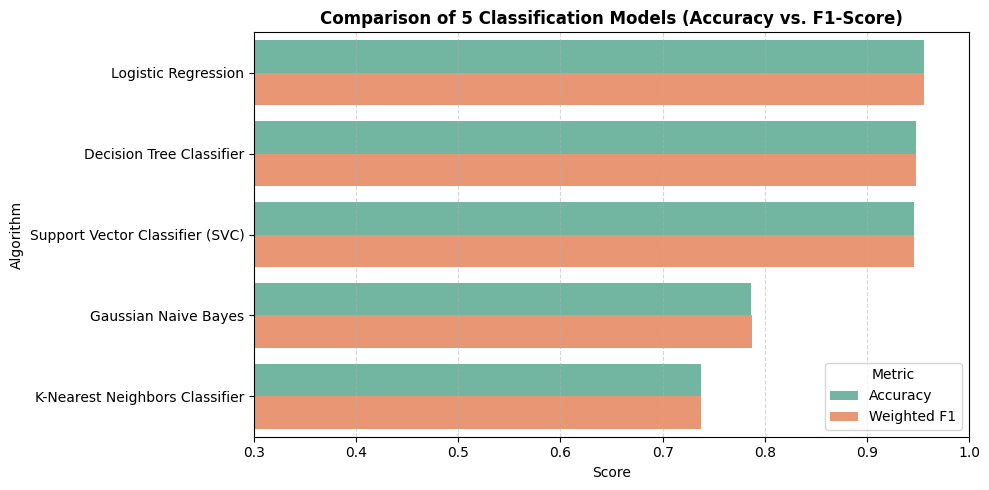

In [22]:
#Classification Model Comparison Bar Plot


import matplotlib.pyplot as plt
import seaborn as sns

# Reshape results for Accuracy vs Weighted F1 comparison
classification_melted = member3_results.melt(
    id_vars=['Algorithm'],
    value_vars=['Accuracy', 'Weighted F1'],
    var_name='Metric',
    value_name='Score'
)

# Create normal-sized figure
plt.figure(figsize=(10, 5))

sns.barplot(
    data=classification_melted,
    x='Score',
    y='Algorithm',
    hue='Metric',
    palette='Set2'
)

plt.title(
    'Comparison of 5 Classification Models (Accuracy vs. F1-Score)',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Score')
plt.ylabel('Algorithm')

plt.xlim(0.3, 1.0)

plt.legend(
    title='Metric',
    loc='lower right'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

### Classification Model Comparison

The bar plot compares the **Accuracy** and **Weighted F1-Score** of the five classification models.

- **Logistic Regression** achieves the highest performance among the five models, with both Accuracy and Weighted F1-Score close to **0.95**.
- **Decision Tree Classifier** and **Support Vector Classifier (SVC)** show similar performance, with scores around **0.93**.
- **Gaussian Naive Bayes** achieves moderate performance, with scores around **0.78**.
- **K-Nearest Neighbors (KNN)** records the lowest performance among the five models, with scores around **0.74**.
- Overall, **Logistic Regression performs best**, while KNN performs weakest based on the displayed Accuracy and Weighted F1-Score.

This comparison helps identify the strongest classifier before further evaluation using the confusion matrix and ROC-AUC.

In [23]:
# ==========================================
# 5-FOLD CROSS VALIDATION - TOP 2 CLASSIFIERS
# Logistic Regression vs Decision Tree
# ==========================================

from sklearn.model_selection import cross_val_score
import pandas as pd

# Use the same training data for both models
X_cv_cls = X_train_cls
y_cv_cls = y_train_cls

# ==========================================
# LOGISTIC REGRESSION - 5 FOLD CV
# ==========================================

cv_scores_log = cross_val_score(
    log_reg,
    X_cv_cls,
    y_cv_cls,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# ==========================================
# DECISION TREE - 5 FOLD CV
# ==========================================

cv_scores_dt_cls = cross_val_score(
    dt_cls,
    X_cv_cls,
    y_cv_cls,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# ==========================================
# CREATE COMPARISON TABLE
# ==========================================

cv_classification_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree Classifier'
    ],

    'Mean Accuracy': [
        cv_scores_log.mean(),
        cv_scores_dt_cls.mean()
    ],

    'Standard Deviation': [
        cv_scores_log.std(),
        cv_scores_dt_cls.std()
    ],

    'Fold 1': [
        cv_scores_log[0],
        cv_scores_dt_cls[0]
    ],

    'Fold 2': [
        cv_scores_log[1],
        cv_scores_dt_cls[1]
    ],

    'Fold 3': [
        cv_scores_log[2],
        cv_scores_dt_cls[2]
    ],

    'Fold 4': [
        cv_scores_log[3],
        cv_scores_dt_cls[3]
    ],

    'Fold 5': [
        cv_scores_log[4],
        cv_scores_dt_cls[4]
    ]
})

# Sort by Mean Accuracy
cv_classification_comparison = (
    cv_classification_comparison
    .sort_values(
        by='Mean Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("5-FOLD CROSS VALIDATION - CLASSIFICATION MODEL COMPARISON")
display(cv_classification_comparison)

5-FOLD CROSS VALIDATION - CLASSIFICATION MODEL COMPARISON


,Model,Mean Accuracy,Standard Deviation,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Logistic Regression,0.956318,0.001615,0.956533,0.957401,0.956800,0.953192,0.957666
1,Decision Tree Classifier,0.947505,0.001432,0.947052,0.948922,0.945984,0.946114,0.949452


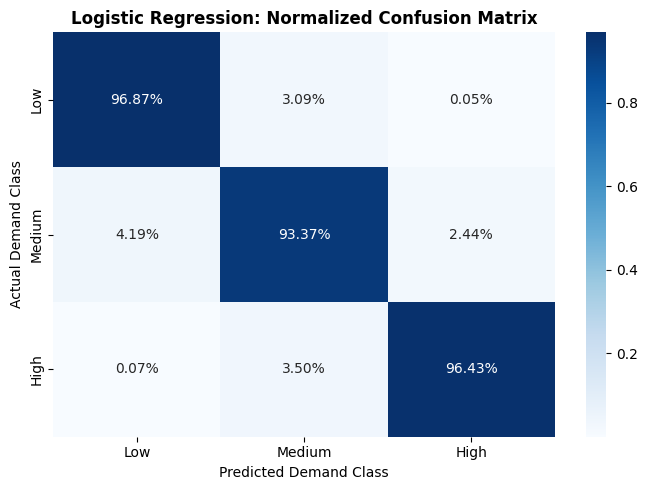

In [24]:
# ==========================================
# CONFUSION MATRIX HEATMAP
# TOP CLASSIFIER: LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import confusion_matrix

# Generate Logistic Regression predictions
y_pred_lr_cls = log_reg.predict(X_test_cls)

# Compute confusion matrix
cm = confusion_matrix(
    y_test_cls,
    y_pred_lr_cls,
    labels=['Low', 'Medium', 'High']
)

# Normalize row-wise
cm_percent = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title(
    'Logistic Regression: Normalized Confusion Matrix',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Predicted Demand Class')
plt.ylabel('Actual Demand Class')

plt.tight_layout()
plt.show()

### Confusion Matrix – Logistic Regression

The normalized confusion matrix shows that the **Logistic Regression classifier performs very well across all three demand categories**.

- **Low Demand:** 96.87% of actual Low-demand trips are correctly classified as Low, while 3.09% are classified as Medium and only 0.05% as High.
- **Medium Demand:** 93.37% of actual Medium-demand trips are correctly classified, with 4.19% misclassified as Low and 2.44% as High.
- **High Demand:** 96.43% of actual High-demand trips are correctly classified as High, while 3.50% are classified as Medium and 0.07% as Low.
- The **diagonal values are high**, indicating strong classification performance.
- Most misclassifications occur between **Low and Medium** or **Medium and High**, while confusion between Low and High is very small.

Overall, the confusion matrix indicates that **Logistic Regression effectively distinguishes between Low, Medium, and High demand categories**.

Logistic Regression class order:
['High' 'Low' 'Medium']

Logistic Regression - ROC-AUC (OvR)
Weighted ROC-AUC: 0.9949


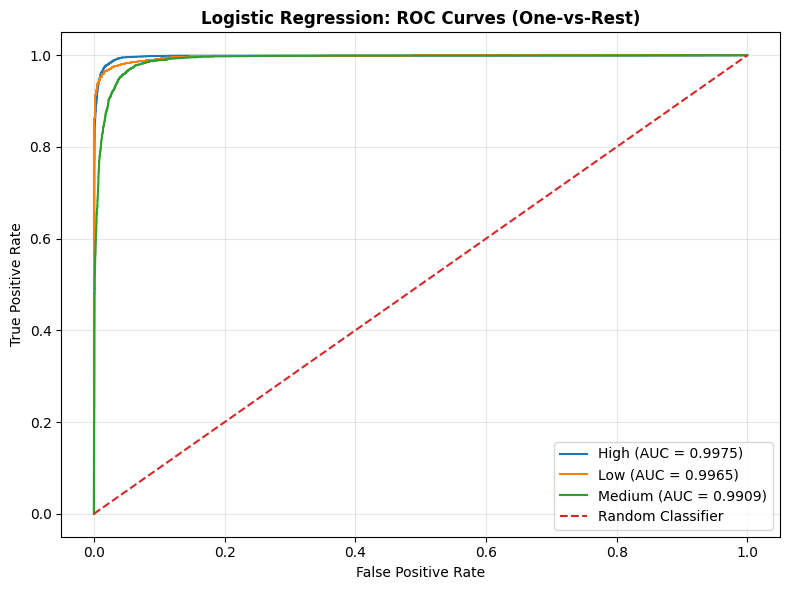

In [27]:
# ==========================================
# ROC-AUC CURVE - LOGISTIC REGRESSION
# ONE-vs-Rest (OvR)
# ==========================================

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get prediction probabilities
y_prob_lr = log_reg.predict_proba(X_test_cls)

# Use the actual class order of Logistic Regression
model_classes = log_reg.classes_

print("Logistic Regression class order:")
print(model_classes)

# Binarize test labels using the SAME class order
y_test_binary = label_binarize(
    y_test_cls,
    classes=model_classes
)

# Calculate weighted multiclass ROC-AUC
lr_roc_auc = roc_auc_score(
    y_test_binary,
    y_prob_lr,
    multi_class='ovr',
    average='weighted'
)

print("\nLogistic Regression - ROC-AUC (OvR)")
print(f"Weighted ROC-AUC: {lr_roc_auc:.4f}")

# ==========================================
# PLOT ROC CURVES
# ==========================================

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(model_classes):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_prob_lr[:, i]
    )

    class_auc = roc_auc_score(
        y_test_binary[:, i],
        y_prob_lr[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {class_auc:.4f})'
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title(
    'Logistic Regression: ROC Curves (One-vs-Rest)',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ROC-AUC Analysis – Logistic Regression

The ROC curves evaluate the ability of the Logistic Regression classifier to distinguish between the **Low, Medium, and High demand classes** using a One-vs-Rest (OvR) approach.

- The **weighted ROC-AUC score is 0.9949**, indicating excellent overall class discrimination.
- The **High-demand class** achieved an AUC of **0.9975**.
- The **Low-demand class** achieved an AUC of **0.9965**.
- The **Medium-demand class** achieved an AUC of **0.9909**.
- All three ROC curves lie well above the random-classifier reference line, demonstrating strong predictive performance.

Overall, Logistic Regression demonstrates **excellent ability to distinguish between the three demand classes**, with consistently high ROC-AUC values across all classes.